Title: SEM_application.ipynb

Purpose: 

Author: Onno Nennecke on 19.03.2025 Modified: 03.05.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Define variables (all in the config file)


```python
Wind:
- alpha_on = 1/7    # Roughness parameter onshore  
- alpha_off = 0.11  # Roughness parameter offshore  
- ref_height = 10   # Height of wind data  
- v_cutin = 3.5     # Minimum wind speed to start producing power  
- v_cutout = 25     # Maximum wind speed to produce power  
- v_rated = 13      # Wind speed at which the turbine produces maximum power  
- time_oper = 24    # operational time of hub [h/day]  
- Hub Height:
    - # hub_height_on = 80    # Approximation: Onshore 80 m --> Bad Approximation --> Used own grid data instead  
    - # hub_height_off = 120  # Approximation: Offshore 120 m --> Bad Approximation --> Used own grid data instead  

Solar:

- cT_c1 = 4.3       # constant [dC]  
- cT_c2 = 0.943     # constant [-]  
- cT_c3 = 0.028     # constant [dC m2 W-1]  
- cT_c4 = -1.528    # constant [dC s m-1]  
- gamma = -0.005    # constant [--]  
- temp_ref = 25     # reference temperature [dC]  
- gstc = 1000       # standard test conditions [W m-2]  
- shift_doy = 186   # if HadGEM : 180  
```

### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']

In [3]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [4]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

### Define used models

In [5]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# ESMs = ['EC-Earth3'] # 'EC-Earth3-Veg'

# ESMs = ['UKESM1-0-LL']
# ESMs = ['TaiEMS1', 'UKESM1-0LL']
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'


In [6]:
# Check which directories are (already) available and if they contain all the variables
# ESMs = ['EC-Earth3']
for ESM in ESMs:
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    print(ESM,': ')
    if len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0])
        print(runs)
        
    else:
        print('No matching directory found')
        continue
    for run in runs:
        run_path = os.path.join(matching_dirs[0], run, 'day')
        print('run_path: ', run_path)
        # Check if all required folders (in `variables`) exist
        # missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        # if missing_folders:
        #     print(f"Missing folders in {run_path}: {missing_folders}")
        #     continue
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue

ACCESS-CM2 : 
['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
run_path:  /climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r4i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r5i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp370/r1i1p1f1/day
BCC-CSM2-MR : 
['r1i1p1f1']
run_path:  /climca/data/CMIP6/ScenarioMIP/BCC/BCC-CSM2-MR/ssp370/r1i1p1f1/day
CESM2 : 
['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
run_path:  /climca/data/CMIP6/ScenarioMIP/NCAR/CESM2/ssp370/r4i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/NCAR/CESM2/ssp370/r10i1p1f1/day
run_path:  /climca/data/CMIP6/ScenarioMIP/NCAR/CESM2/ssp370/r11i1p1f1/day
EC-Earth3 : 
['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r12

In [7]:
# Only the loading part of the model for testing 
'''
# List to hold individual datasets (one for each variable)
ds_list = []

for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/ScenarioMIP/*/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        print('Run: ', run)
        run_path = os.path.join(matching_dirs[0], run, 'day/')
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        for variable in variables:
            print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/ScenarioMIP/*/{ESM}/{scenario}/{run}/day/{variable}/*/*/{variable}_day_{ESM}_{scenario}_{run}_*'
            print('Open: ', path)
            # Open with preprocessing (spatial filtering)
            nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter to only winter months (October to March)
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        # if ds_list[2]['tas'].units == 'K':
        #     clim_ds['tas'] = clim_ds['tas'] - 273.15

        # if ds_list[3]['tasmax'].units == 'K':
        #     clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # # Regrid the combined dataset
        # combined_ds = grid_func.regrid(clim_ds)
        
        break
'''

'\n# List to hold individual datasets (one for each variable)\nds_list = []\n\nfor ESM in ESMs:\n    print(\'ESM: \', ESM)\n    path = f\'/climca/data/CMIP6/ScenarioMIP/*/{ESM}/{scenario}/\'\n    matching_dirs = glob.glob(path)\n    if len(matching_dirs) == 1:\n        runs = os.listdir(matching_dirs[0])\n    else:\n        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")\n        break\n    print(\'Runs: \', runs)\n    for run in runs:\n        print(\'Run: \', run)\n        run_path = os.path.join(matching_dirs[0], run, \'day/\')\n\n        # Check if all required folders (in `variables`) exist\n        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]\n\n        if missing_folders:\n            print(f"Missing folders in {run_path}: {missing_folders}")\n            continue\n        for variable in variables:\n            print(\'Variable: \', variable)\n            #path =f\'/climca/data/CMIP6/CMIP/NCAR/

In [8]:
# Takes about 3:30h
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
        # continue # Only for the last model
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
        #     # Filter to only winter months (October to March)
        #     # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, config.a_offshore, config.height_ref)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, config.height_ref)
        
        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']
        
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)
        
        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']
        
        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], combined_ds['sfcWind'])
        
        # combined_ds['solar_pot'] = sepot['solar_pot']        
        combined_ds['solar_pot'] = sepot
        
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)
        
        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod

        
        # Calculate weighted sum

        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
        
        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))
        
        timeseries_ds = demand_ds.copy()

        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        
        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000
        
        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        ts_output.load()
        # print('Saving')
        ts_output.to_netcdf(f'/climca/people/onennecke/model_output/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
        # break
    # break

ESM:  ACCESS-CM2
Runs:  ['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
Run:  r4i1p1f1 Number:  1 of  3
Run time:  3 m 16.3 s
Run:  r5i1p1f1 Number:  2 of  3
Run time:  3 m 17.3 s
Run:  r1i1p1f1 Number:  3 of  3
Run time:  3 m 17.0 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 35.3 s
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
Run:  r4i1p1f1 Number:  1 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  3 m 2.3 s
Run:  r10i1p1f1 Number:  2 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  3 m 2.6 s
Run:  r11i1p1f1 Number:  3 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run time:  3 m 6.1 s
ESM:  EC-Earth3
Runs:  ['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r128i1p1f1', 'r135i1p1f1', 'r110i1p1f1', 'r129i1p1f1', 'r132i1p1f1', 'r101i1p1f1', 'r124i1p1f1', 'r127i1p1f1', 'r116i1p1f1', 'r131i1p1f1', 'r121i1p1f1', 'r142i1p1f1', 'r102i1p1f1', 'r133i1p1f1', 'r111i1p1f1', 'r140i1p1f1', 'r136i1p1f1', 'r108i1p1f1', 'r130i1p1f1', 'r150i1p1f1', 'r104i1p1f1', 'r118i1p1f1', 'r109i1p1f1', 'r143i1p1f1', 'r147i1p1f1', 'r126i1p1f1', 'r13i1p1f1', 'r119i1p1f1', 'r1i1p1f1', 'r123i1p1f1', 'r122i1p1f1', 'r115i1p1f1', 'r103i1p1f1', 'r144i1p1f1', 'r139i1p1f1', 'r107i1p1f1']
Run:  r149i1p1f1 Number:  1 of  58
Run time:  4 m 10.0 s
Run:  r6i1p1f1 Number:  2 of  58
Missing data in /climca/data/CMIP6/ScenarioMIP/EC-Earth-Consortium

#### Some plots to check everything is alright

In [9]:
# Common gridline function
def setup_gridlines(ax):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(2)
    gl.ylocator = MultipleLocator(2)

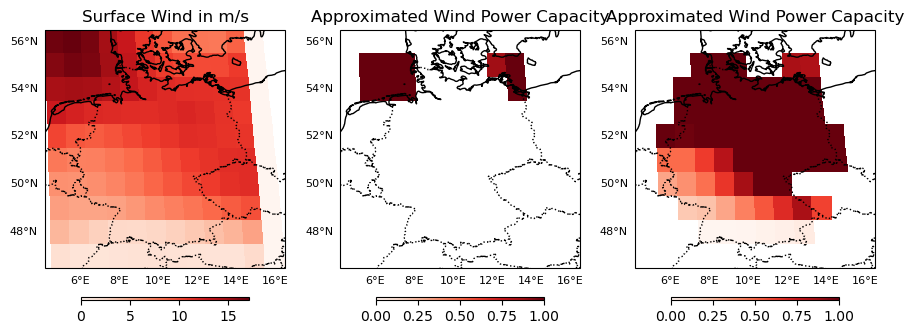

In [10]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 2

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['sfcWind'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax3)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')


plt.tight_layout()
plt.show()


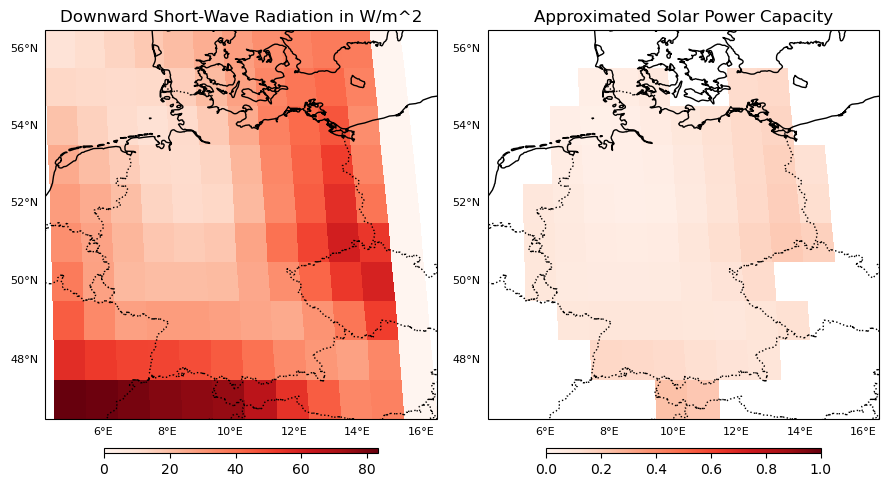

In [11]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 14# 29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

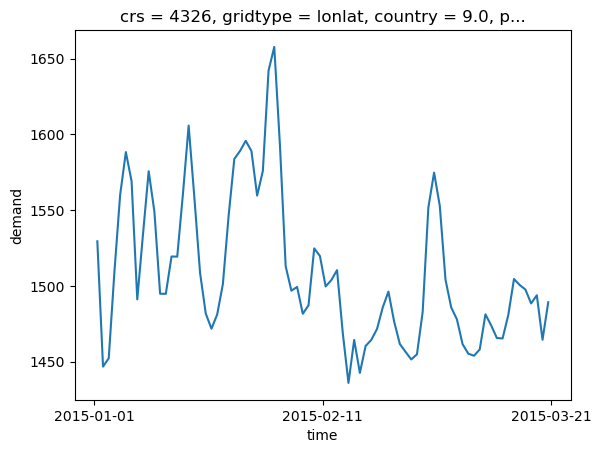

In [12]:
demand_ds['demand'][0:80].plot()

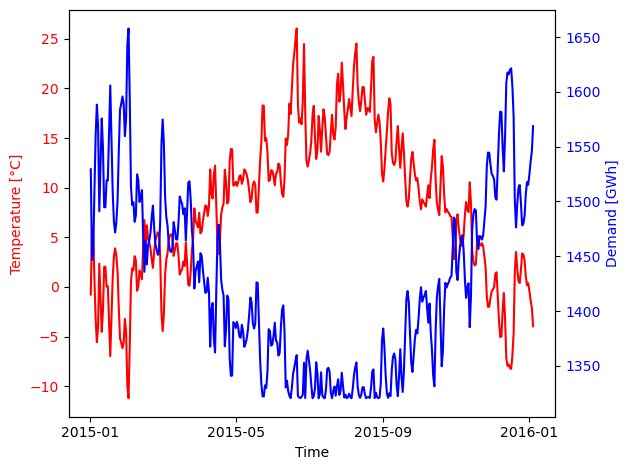

In [13]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

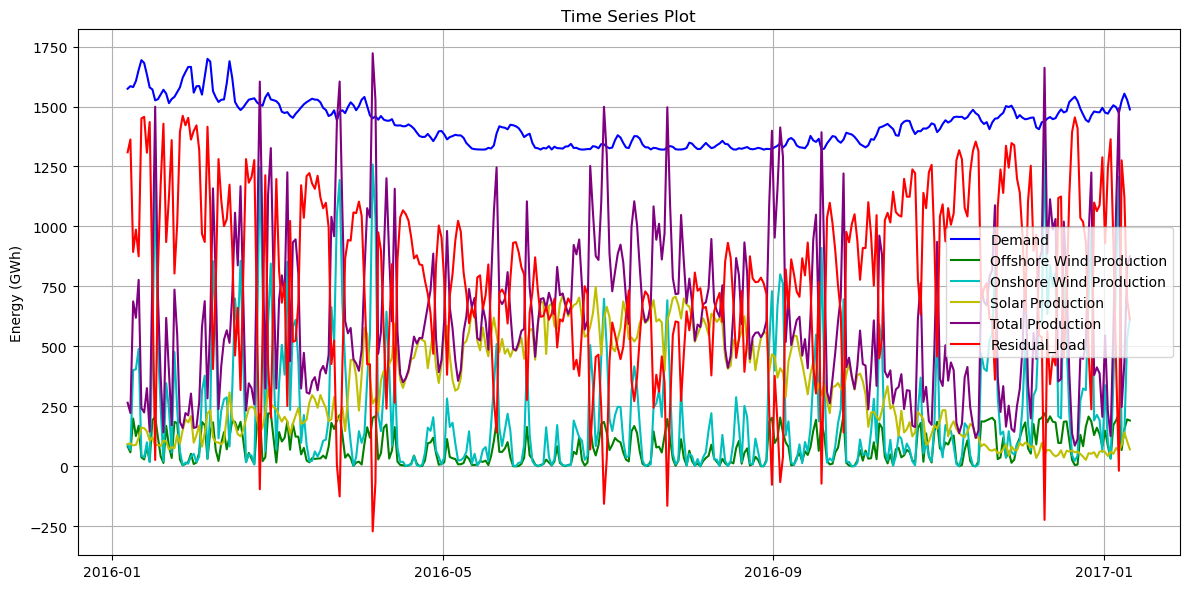

In [14]:

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
# a = 0
# b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

